# Long-Term Retention Analysis

This notebook studies long-term player retention as a function of the variables available in `data/`.

We do not have multiplayer status or review-score data for this dataset, so the analysis focuses on the predictors that are available locally: free-to-play status, release year, estimated owners, peak concurrent players, and base price where applicable.


## Scope

The outcome is the long-term retention ratio, defined as the recent 12-month average player count divided by each game's own historical peak average player count.

Because multiplayer status and review score are not present in the local data, the analysis uses the variables we do have: free-to-play status, release year, estimated owners, and launch peak concurrent players.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf

REPO = Path.cwd()
DATA = REPO / "data"


Below are helper functions for processing the data.

In [13]:
def _parse_owner_token(token: str) -> float:
    token = str(token).strip().replace(",", "").replace("+", "")
    if token.endswith("M"):
        return float(token[:-1]) * 1_000_000
    if token.endswith("K"):
        return float(token[:-1]) * 1_000
    return float(token)


def parse_owner_range(value: str) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if "-" in text:
        low, high = [part.strip() for part in text.split("-")]
        return (_parse_owner_token(low) + _parse_owner_token(high)) / 2
    return _parse_owner_token(text)


def load_tables():
    free_players = pd.read_csv(DATA / "top50_free_games_player_data.csv")
    paid_players = pd.read_csv(DATA / "top50_paid_games_player_data.csv")
    free_list = pd.read_csv(DATA / "top50_free_games_list.csv")
    paid_list = pd.read_csv(DATA / "top50_paid_games_list.csv")

    free_players["group"] = "Free-to-play"
    paid_players["group"] = "Paid"
    players = pd.concat([free_players, paid_players], ignore_index=True)
    players["year_month"] = pd.to_datetime(players["year_month"], format="%Y-%m")
    players = players.loc[players["average_player_count"] > 0].copy()

    free_list = free_list.rename(columns={
        "AppID": "game_id",
        "Game Title": "game_name",
        "Release Date": "release_date",
        "Estimated Owners": "estimated_owners",
        "Peak Concurrent Players (24h)": "launch_peak_concurrent_players",
    })
    paid_list = paid_list.rename(columns={
        "AppID": "game_id",
        "Game Title": "game_name",
        "Release Date": "release_date",
        "Base Price": "base_price",
        "Estimated Owners": "estimated_owners",
        "Peak Concurrent Players (24h)": "launch_peak_concurrent_players",
    })
    free_list["base_price"] = 0.0
    free_list["group"] = "Free-to-play"
    paid_list["group"] = "Paid"

    games = pd.concat([free_list, paid_list], ignore_index=True)
    games["release_date"] = pd.to_datetime(games["release_date"], errors="coerce")
    games["release_year"] = games["release_date"].dt.year
    games["estimated_owners_mid"] = games["estimated_owners"].apply(parse_owner_range)
    games["base_price"] = pd.to_numeric(
        games["base_price"].astype(str).str.replace("$", "", regex=False),
        errors="coerce",
    )
    games["log_estimated_owners"] = np.log10(games["estimated_owners_mid"].where(games["estimated_owners_mid"] > 0))
    games["log_launch_peak_concurrent_players"] = np.log10(
        games["launch_peak_concurrent_players"].where(games["launch_peak_concurrent_players"] > 0)
    )

    return players, games

def build_game_features(players, games):
    rows = []
    for (game_id, group), group_frame in players.groupby(["game_id", "group"]):
        group_frame = group_frame.sort_values("year_month")
        values = group_frame["average_player_count"].to_numpy(dtype=float)
        peak_avg = values.max()
        recent_avg = group_frame.tail(12)["average_player_count"].mean()
        rows.append({
            "game_id": game_id,
            "group": group,
            "n_months": len(group_frame),
            "first_month": group_frame["year_month"].min(),
            "last_month": group_frame["year_month"].max(),
            "peak_avg": peak_avg,
            "recent_avg": recent_avg,
            "retention_ratio": recent_avg / peak_avg if peak_avg > 0 else np.nan,
            "peak_position": int(values.argmax()) / (len(values) - 1) if len(values) > 1 else 0.0,
            "months_above_half_peak": np.mean(values >= 0.5 * peak_avg),
        })

    features = pd.DataFrame(rows).merge(
        games[[
            "game_id",
            "game_name",
            "release_year",
            "estimated_owners_mid",
            "log_estimated_owners",
            "launch_peak_concurrent_players",
            "log_launch_peak_concurrent_players",
            "base_price",
        ]],
        on="game_id",
        how="left",
    )
    features["is_free_to_play"] = (features["group"] == "Free-to-play").astype(int)
    features["log_retention_ratio"] = np.log(features["retention_ratio"])
    features["release_year_centered"] = features["release_year"] - features["release_year"].mean()
    return features


def summarize_by_group(features, columns):
    records = []
    for column in columns:
        for group_name, group_frame in features.groupby("group"):
            series = group_frame[column].dropna()
            records.append({
                "group": group_name,
                "metric": column,
                "n": int(series.shape[0]),
                "mean": series.mean(),
                "median": series.median(),
                "std": series.std(ddof=1),
                "min": series.min(),
                "max": series.max(),
            })
    return pd.DataFrame(records)

## Analysis 
First, attach a `retention_ratio` column for each game.


In [4]:
players, games = load_tables()
features = build_game_features(players, games)

analysis_columns = [
    "game_name",
    "group",
    "release_year",
    "estimated_owners_mid",
    "launch_peak_concurrent_players",
    "peak_avg",
    "recent_avg",
    "retention_ratio",
]

print(f"Games analyzed: {features.shape[0]}")
print(f"Free-to-play games: {(features['group'] == 'Free-to-play').sum()}")
print(f"Paid games: {(features['group'] == 'Paid').sum()}")
print()
print(features[analysis_columns].head(10).to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

summary = summarize_by_group(
    features,
    ["retention_ratio", "peak_avg", "recent_avg", "release_year", "estimated_owners_mid"],
)
summary


Games analyzed: 97
Free-to-play games: 47
Paid games: 50

                    game_name        group  release_year  estimated_owners_mid  launch_peak_concurrent_players     peak_avg  recent_avg  retention_ratio
              Team Fortress 2 Free-to-play          2007         35,000,000.00                           67712   118,906.77   47,170.84             0.40
                Left 4 Dead 2         Paid          2009         35,000,000.00                           18706    34,798.59   22,551.43             0.65
                       Dota 2 Free-to-play          2013        100,000,000.00                          632090   709,178.26  512,258.28             0.72
             Counter-Strike 2 Free-to-play          2012        100,000,000.00                         1415913 1,117,517.40  995,213.42             0.89
                  Garry's Mod         Paid          2006         35,000,000.00                           30201    38,758.97   20,124.29             0.52
Grand Theft Auto IV: Com

,group,metric,n,mean,median,std,min,max
0,Free-to-play,retention_ratio,47,2.721248e-01,1.499033e-01,2.892160e-01,6.731268e-04,8.905574e-01
1,Paid,retention_ratio,50,3.298670e-01,2.813359e-01,2.532749e-01,1.298204e-02,9.185781e-01
2,Free-to-play,peak_avg,47,1.143975e+05,7.216470e+03,3.057648e+05,1.039600e+02,1.584887e+06
3,Paid,peak_avg,50,9.521259e+04,3.171672e+04,2.122561e+05,4.401870e+03,1.146060e+06
4,Free-to-play,recent_avg,47,4.642043e+04,8.145217e+02,1.654757e+05,2.641667e+00,9.952134e+05
5,Paid,recent_avg,50,1.467699e+04,8.580955e+03,1.875541e+04,4.981842e+02,1.040906e+05
6,Free-to-play,release_year,47,2.017213e+03,2.017000e+03,3.850105e+00,2.007000e+03,2.024000e+03
7,Paid,release_year,50,2.017800e+03,2.018500e+03,4.105745e+00,2.006000e+03,2.024000e+03
8,Free-to-play,estimated_owners_mid,47,1.771809e+07,7.500000e+06,2.529949e+07,7.500000e+05,1.000000e+08
9,Paid,estimated_owners_mid,50,1.225000e+07,7.500000e+06,1.186929e+07,7.500000e+06,7.500000e+07


There are some important notes about the data processed. 
- The dataset provided has an estimated owners column, so to make it friendly to analyze, this was modified to be a column that takes the middle of the specified range of ownership.
- We originally wanted to include whether a game was considered "multiplayer" and review scores, but this data was not obtained. Therefore, we have less variables to consider.

Now, fit a multivariable regression using the predictors available in `data/`.

In [12]:
regression_frame = features.dropna(subset=[
    "log_retention_ratio",
    "is_free_to_play",
    "release_year_centered",
    "log_estimated_owners",
    "log_launch_peak_concurrent_players",
]).copy()

formula = "log_retention_ratio ~ is_free_to_play + release_year_centered + log_estimated_owners + log_launch_peak_concurrent_players"
sm_model = smf.ols(formula, data=regression_frame).fit()
print(sm_model.summary())

                             OLS Regression Results                            
Dep. Variable:     log_retention_ratio   R-squared:                       0.250
Model:                             OLS   Adj. R-squared:                  0.217
Method:                  Least Squares   F-statistic:                     7.580
Date:                 Sat, 30 May 2026   Prob (F-statistic):           2.57e-05
Time:                         22:16:39   Log-Likelihood:                -165.09
No. Observations:                   96   AIC:                             340.2
Df Residuals:                       91   BIC:                             353.0
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Regression Interpretation
- **R-squared:** 0.25 (96 observations).
- **Release year:** coefficient = -0.0981 (p = 0.016); each year later ≈ 9.3% lower retention.
- **Launch peak players:** coefficient = 0.5707 (p < 0.001); roughly +77% retention per 10× increase in launch peak players.
- **Free-to-play:** coefficient = -0.4964 (p = 0.092); about −39% retention (marginal significance).


## Correlation View

`estimated_owners_mid` is the midpoint of the estimated owner range from the Steam list data. For example, `5M - 10M` becomes `7.5M`, and `20M - 50M` becomes `35M`. It gives the range a single numeric value so we can use it in correlation and regression analyses.

The next block shows a compact correlation heatmap for the available numeric predictors. This is the clearest visual summary of which variables have the strongest relationship with long-term retention ratio.


Absolute Pearson correlation with log(retention ratio):
log_recent_avg                       0.681
log_launch_peak_concurrent_players   0.422
log_estimated_owners_mid             0.166
release_year                         0.096
log_peak_avg                         0.000


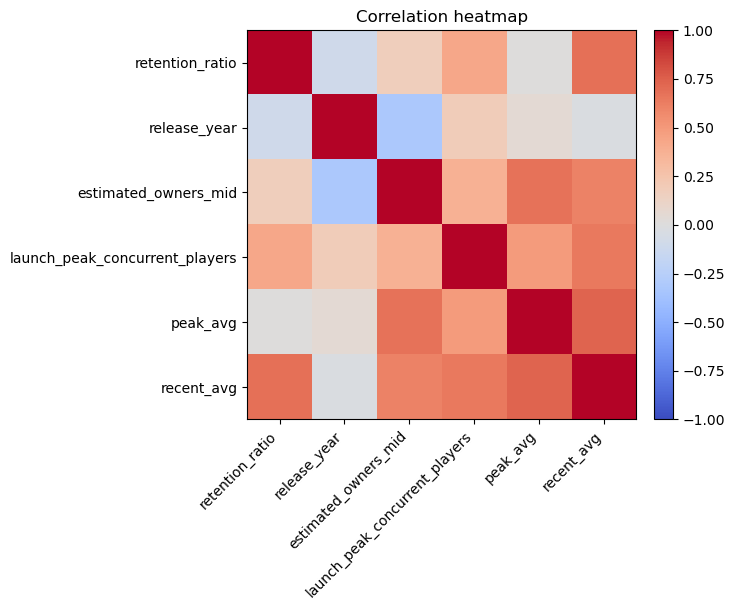

In [6]:
corr_frame = features[[
    "retention_ratio",
    "release_year",
    "estimated_owners_mid",
    "launch_peak_concurrent_players",
    "peak_avg",
    "recent_avg",
]].dropna().copy()

corr_frame["log_estimated_owners_mid"] = np.log10(corr_frame["estimated_owners_mid"].where(corr_frame["estimated_owners_mid"] > 0))
corr_frame["log_launch_peak_concurrent_players"] = np.log10(
    corr_frame["launch_peak_concurrent_players"].where(corr_frame["launch_peak_concurrent_players"] > 0)
)
corr_frame["log_peak_avg"] = np.log10(corr_frame["peak_avg"].where(corr_frame["peak_avg"] > 0))
corr_frame["log_recent_avg"] = np.log10(corr_frame["recent_avg"].where(corr_frame["recent_avg"] > 0))
corr_frame["log_retention_ratio"] = np.log(corr_frame["retention_ratio"].where(corr_frame["retention_ratio"] > 0))

corr_cols = [
    "log_retention_ratio",
    "release_year",
    "log_estimated_owners_mid",
    "log_launch_peak_concurrent_players",
    "log_peak_avg",
    "log_recent_avg",
]

corr = corr_frame[corr_cols].replace([np.inf, -np.inf], np.nan).corr(numeric_only=True)
strength = corr["log_retention_ratio"].drop("log_retention_ratio").abs().sort_values(ascending=False)
print("Absolute Pearson correlation with log(retention ratio):")
print(strength.to_string(float_format=lambda x: f"{x:.3f}"))

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels([c.replace("log_", "") for c in corr_cols], rotation=45, ha="right")
ax.set_yticklabels([c.replace("log_", "") for c in corr_cols])
ax.set_title("Correlation heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
